###### 132_7_practical_task_type_ranking_answer.ipynb

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
plt.rcParams["font.family"] = "Meiryo"
plt.rcParams["axes.unicode_minus"] = False

In [4]:
df = pd.read_csv(
    "dataset/daily_work_minutes_practice.csv",
)
df

,work_date,task_type,work_minutes,comment
0,2022-01-01,集計,45,日次集計
1,2022-01-01,確認,30,内容確認
2,2022-01-02,資料作成,60,会議資料
3,2022-01-04,集計,90,空白あり
4,2022-01-05,確認,未入力,数値NG
5,2022-01-07,会議,120,週次会議
6,2022/01/07,議事録,40,日付表記違い
7,2022-01-09,集計,75,日次集計
8,NG_DATE,確認,30,日付NG
9,2022-01-10,資料作成,abc,数値NG


In [5]:
df["work_date_raw"] = df["work_date"]
df

,work_date,task_type,work_minutes,comment,work_date_raw
0,2022-01-01,集計,45,日次集計,2022-01-01
1,2022-01-01,確認,30,内容確認,2022-01-01
2,2022-01-02,資料作成,60,会議資料,2022-01-02
3,2022-01-04,集計,90,空白あり,2022-01-04
4,2022-01-05,確認,未入力,数値NG,2022-01-05
5,2022-01-07,会議,120,週次会議,2022-01-07
6,2022/01/07,議事録,40,日付表記違い,2022/01/07
7,2022-01-09,集計,75,日次集計,2022-01-09
8,NG_DATE,確認,30,日付NG,NG_DATE
9,2022-01-10,資料作成,abc,数値NG,2022-01-10


In [6]:
df["work_date_clean"] = (
    df["work_date"]
    .astype("string")
    .str.strip()
)
df

,work_date,task_type,work_minutes,comment,work_date_raw,work_date_clean
0,2022-01-01,集計,45,日次集計,2022-01-01,2022-01-01
1,2022-01-01,確認,30,内容確認,2022-01-01,2022-01-01
2,2022-01-02,資料作成,60,会議資料,2022-01-02,2022-01-02
3,2022-01-04,集計,90,空白あり,2022-01-04,2022-01-04
4,2022-01-05,確認,未入力,数値NG,2022-01-05,2022-01-05
5,2022-01-07,会議,120,週次会議,2022-01-07,2022-01-07
6,2022/01/07,議事録,40,日付表記違い,2022/01/07,2022/01/07
7,2022-01-09,集計,75,日次集計,2022-01-09,2022-01-09
8,NG_DATE,確認,30,日付NG,NG_DATE,NG_DATE
9,2022-01-10,資料作成,abc,数値NG,2022-01-10,2022-01-10


In [7]:
df["work_date_clean"].dtypes

<StringDtype(na_value=<NA>)>

In [8]:
df["work_date_dt"] = pd.to_datetime(
    df["work_date_clean"],
    errors="coerce",
    format="mixed",
)
df

,work_date,task_type,work_minutes,comment,work_date_raw,work_date_clean,work_date_dt
0,2022-01-01,集計,45,日次集計,2022-01-01,2022-01-01,2022-01-01
1,2022-01-01,確認,30,内容確認,2022-01-01,2022-01-01,2022-01-01
2,2022-01-02,資料作成,60,会議資料,2022-01-02,2022-01-02,2022-01-02
3,2022-01-04,集計,90,空白あり,2022-01-04,2022-01-04,2022-01-04
4,2022-01-05,確認,未入力,数値NG,2022-01-05,2022-01-05,2022-01-05
5,2022-01-07,会議,120,週次会議,2022-01-07,2022-01-07,2022-01-07
6,2022/01/07,議事録,40,日付表記違い,2022/01/07,2022/01/07,2022-01-07
7,2022-01-09,集計,75,日次集計,2022-01-09,2022-01-09,2022-01-09
8,NG_DATE,確認,30,日付NG,NG_DATE,NG_DATE,NaT
9,2022-01-10,資料作成,abc,数値NG,2022-01-10,2022-01-10,2022-01-10


In [10]:
df["work_date_dt"].dtypes

dtype('<M8[us]')

In [11]:
df["task_type_clean"] = (
    df["task_type"]
    .astype("string")
    .str.strip()
)
df

,work_date,task_type,work_minutes,comment,work_date_raw,work_date_clean,work_date_dt,task_type_clean
0,2022-01-01,集計,45,日次集計,2022-01-01,2022-01-01,2022-01-01,集計
1,2022-01-01,確認,30,内容確認,2022-01-01,2022-01-01,2022-01-01,確認
2,2022-01-02,資料作成,60,会議資料,2022-01-02,2022-01-02,2022-01-02,資料作成
3,2022-01-04,集計,90,空白あり,2022-01-04,2022-01-04,2022-01-04,集計
4,2022-01-05,確認,未入力,数値NG,2022-01-05,2022-01-05,2022-01-05,確認
5,2022-01-07,会議,120,週次会議,2022-01-07,2022-01-07,2022-01-07,会議
6,2022/01/07,議事録,40,日付表記違い,2022/01/07,2022/01/07,2022-01-07,議事録
7,2022-01-09,集計,75,日次集計,2022-01-09,2022-01-09,2022-01-09,集計
8,NG_DATE,確認,30,日付NG,NG_DATE,NG_DATE,NaT,確認
9,2022-01-10,資料作成,abc,数値NG,2022-01-10,2022-01-10,2022-01-10,資料作成


In [12]:
#cell8
df["work_minutes_clean"] = (
    df["work_minutes"]
    .astype("string")
    .str.strip()
)
df

,work_date,task_type,work_minutes,comment,work_date_raw,work_date_clean,work_date_dt,task_type_clean,work_minutes_clean
0,2022-01-01,集計,45,日次集計,2022-01-01,2022-01-01,2022-01-01,集計,45
1,2022-01-01,確認,30,内容確認,2022-01-01,2022-01-01,2022-01-01,確認,30
2,2022-01-02,資料作成,60,会議資料,2022-01-02,2022-01-02,2022-01-02,資料作成,60
3,2022-01-04,集計,90,空白あり,2022-01-04,2022-01-04,2022-01-04,集計,90
4,2022-01-05,確認,未入力,数値NG,2022-01-05,2022-01-05,2022-01-05,確認,未入力
5,2022-01-07,会議,120,週次会議,2022-01-07,2022-01-07,2022-01-07,会議,120
6,2022/01/07,議事録,40,日付表記違い,2022/01/07,2022/01/07,2022-01-07,議事録,40
7,2022-01-09,集計,75,日次集計,2022-01-09,2022-01-09,2022-01-09,集計,75
8,NG_DATE,確認,30,日付NG,NG_DATE,NG_DATE,NaT,確認,30
9,2022-01-10,資料作成,abc,数値NG,2022-01-10,2022-01-10,2022-01-10,資料作成,abc


In [13]:
df["work_minutes_clean"].dtypes

<StringDtype(na_value=<NA>)>

In [14]:
df["work_minutes_num"] = pd.to_numeric(
    df["work_minutes_clean"],
    errors="coerce",
)
df

,work_date,task_type,work_minutes,comment,work_date_raw,work_date_clean,work_date_dt,task_type_clean,work_minutes_clean,work_minutes_num
0,2022-01-01,集計,45,日次集計,2022-01-01,2022-01-01,2022-01-01,集計,45,45
1,2022-01-01,確認,30,内容確認,2022-01-01,2022-01-01,2022-01-01,確認,30,30
2,2022-01-02,資料作成,60,会議資料,2022-01-02,2022-01-02,2022-01-02,資料作成,60,60
3,2022-01-04,集計,90,空白あり,2022-01-04,2022-01-04,2022-01-04,集計,90,90
4,2022-01-05,確認,未入力,数値NG,2022-01-05,2022-01-05,2022-01-05,確認,未入力,<NA>
5,2022-01-07,会議,120,週次会議,2022-01-07,2022-01-07,2022-01-07,会議,120,120
6,2022/01/07,議事録,40,日付表記違い,2022/01/07,2022/01/07,2022-01-07,議事録,40,40
7,2022-01-09,集計,75,日次集計,2022-01-09,2022-01-09,2022-01-09,集計,75,75
8,NG_DATE,確認,30,日付NG,NG_DATE,NG_DATE,NaT,確認,30,30
9,2022-01-10,資料作成,abc,数値NG,2022-01-10,2022-01-10,2022-01-10,資料作成,abc,<NA>


In [15]:
df["work_minutes_num"].dtypes

Int64Dtype()

In [16]:
df_date_ng = df[
    df["work_date_dt"].isna()
].copy()
df_date_ng

,work_date,task_type,work_minutes,comment,work_date_raw,work_date_clean,work_date_dt,task_type_clean,work_minutes_clean,work_minutes_num
8,NG_DATE,確認,30,日付NG,NG_DATE,NG_DATE,NaT,確認,30,30


In [17]:
#cell11
df_minutes_ng = df[
    df["work_minutes_num"].isna()
].copy()
df_minutes_ng

,work_date,task_type,work_minutes,comment,work_date_raw,work_date_clean,work_date_dt,task_type_clean,work_minutes_clean,work_minutes_num
4,2022-01-05,確認,未入力,数値NG,2022-01-05,2022-01-05,2022-01-05,確認,未入力,<NA>
9,2022-01-10,資料作成,abc,数値NG,2022-01-10,2022-01-10,2022-01-10,資料作成,abc,<NA>


In [18]:
df_work = df[
    df["work_date_dt"].notna()
    & df["work_minutes_num"].notna()
    & df["task_type_clean"].notna()
].copy()
df_work

,work_date,task_type,work_minutes,comment,work_date_raw,work_date_clean,work_date_dt,task_type_clean,work_minutes_clean,work_minutes_num
0,2022-01-01,集計,45,日次集計,2022-01-01,2022-01-01,2022-01-01,集計,45,45
1,2022-01-01,確認,30,内容確認,2022-01-01,2022-01-01,2022-01-01,確認,30,30
2,2022-01-02,資料作成,60,会議資料,2022-01-02,2022-01-02,2022-01-02,資料作成,60,60
3,2022-01-04,集計,90,空白あり,2022-01-04,2022-01-04,2022-01-04,集計,90,90
5,2022-01-07,会議,120,週次会議,2022-01-07,2022-01-07,2022-01-07,会議,120,120
6,2022/01/07,議事録,40,日付表記違い,2022/01/07,2022/01/07,2022-01-07,議事録,40,40
7,2022-01-09,集計,75,日次集計,2022-01-09,2022-01-09,2022-01-09,集計,75,75
10,2022-01-10,確認,35,内容確認,2022-01-10,2022-01-10,2022-01-10,確認,35,35


In [19]:
task_summary = (
    df_work
    .groupby("task_type_clean", as_index=False)
    .agg(
        work_minutes_sum=("work_minutes_num", "sum"),
        record_count=("work_minutes_num", "count"),
    )
    .sort_values("work_minutes_sum", ascending=False)
    .reset_index(drop=True)
)
task_summary

,task_type_clean,work_minutes_sum,record_count
0,集計,210,3
1,会議,120,1
2,確認,65,2
3,資料作成,60,1
4,議事録,40,1


In [20]:
#cell 14
task_summary["share_rate"] = (
    task_summary["work_minutes_sum"]
    / task_summary["work_minutes_sum"].sum()
    * 100
).round(1)

In [21]:
task_summary

,task_type_clean,work_minutes_sum,record_count,share_rate
0,集計,210,3,42.4
1,会議,120,1,24.2
2,確認,65,2,13.1
3,資料作成,60,1,12.1
4,議事録,40,1,8.1


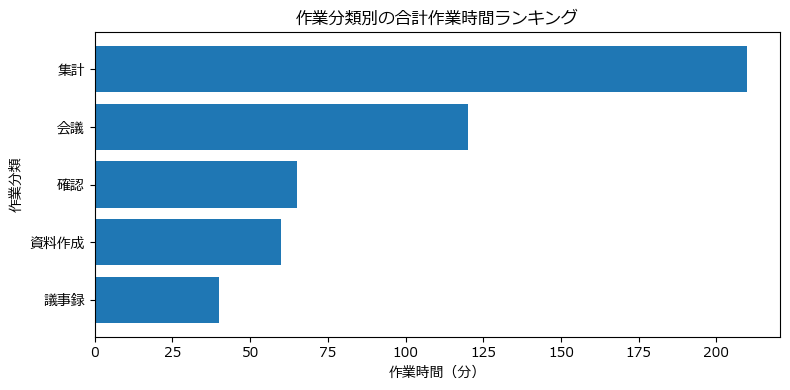

In [29]:
plt.figure(figsize=(8, 4))

plt.barh(
    task_summary["task_type_clean"],
    task_summary["work_minutes_sum"],
)

plt.title("作業分類別の合計作業時間ランキング")
plt.xlabel("作業時間（分）")
plt.ylabel("作業分類")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()